VALUTAZIONE DEI MODELLI NLP

La valutazione dei modelli NLP è capire quanto bene un modello funziona su daati che non ha visto durante il training.
Non esiste una sola metrica valida per tutti i problemi NLP. 
La metrica dinde dal task

classificazione testo → Accuracy, Precision, Recall, F1
NER → Precision, Recall, F1 sulle entità
Language Model → Cross-Entropy, Perplexity
Traduzione → BLEU
Riassunto → ROUGE
similarità semantica → cosine similarity / correlazioni / metriche specifiche

* Classificazione

Una volta costruito un modello, come facciamo a sapere se è davvero utile o se ci sta semplicemente mentendo?

Supponiamo di avere 'spam' 'non spam' il modello produce delle predizioni e le confrontiamo con le etichette vere.
Qui nasce la confusion matrix
reale spam: predetta spam TP (true positive), predetta non spam FN (false negative)
reale non spam: predetta spam FP (false positive), predetta non spam TN (true negative)
TP = True Positive: spam correttamente riconosciuto
TN = True Negative: non spam correttamente riconosciuto
FP = False Positive: email buona classificata come spam
FN = False Negative: spam classificato come email buona

L'Accuracy risponde alla domanda: "quanto predizioni totali sono corrette?" 
Concettualmente: predizioni corrette / predizioni totali
esempio:
email=1.000
corrette = 950 (divise tra 950 ham e 50 spam)
Accuracy del 95%
Ma se il modello dovesse risondere sempre rispondere ham avrebbe comunque un'accuracy del 95% anche se non trova mail le mail spam.

Quindi l'accuracy, come metrica, non basta, qui entrano in gioco Recall e Precision

La Precision dice: "Quando il modello dice 'spam' quante volte ha ragione?" (quando dico spam, quanto sono affidabile?)
nel caso dello spam è importante perchè non vuoi buttare email legettime nella cartella spam.
La Recall dice: "di tutto lo spam realmente presente, quante ne ho trovate?" (quanto spam riesco effettivaame a trovaree?)
una recall alta vuol dire avere pochi falsi negativi.

Precision aala + recall alto -> F1 alto
L'F1 Score è una media armonica delle due grandezze e penalizza situazioni in cui una delle due metriche è molto bassa.

Accuracy → correttezza globale
Precision → affidabilità delle predizioni positive
Recall → capacità di recuperare i positivi reali
F1 → compromesso Precision/Recall 

La bussodi ogni data scientice
La Matrice di Confusione
Oltre il semplice conteggio delle predizioni corrette.
In molti problemi di NLP, l'accuratezza può essere fuorviante. Se abbiamo un dataset per il rilevamento di messaggi spam dove solo il 5% è effettivamente spam, un modello che predice sempre 'non spam' avrebbe un'accuratezza del 95%, pur essendo totalmente inutile.
La matrice do confusione ci permette di smascherare questo inganno.
La Matrice di Confusione ci permette di scomporre la performance del modello analizzando come le classi reali si incrociano con le predizioni. Questo strumento è fondamentale per capire se il nostro sistema sta sistematicamente confendondo due categorie specifiche.

In modello può trovarsi in 4 situazioni.
* True Positive (TP): il modello ha predetto correttamente la classe positiva
* True Negative (TN): il modello ha predetto correttamente la classe negativa
* False Positive (FP): il modello ha predetto erroneamente la classe negativa (la classe è positiva)
* False Negative (FN): il modello ha predetto erroneamente la classe positiva (la classe è negativa)
La matrice rappresentata come una tabella dove le righe indicano la classe reale e le colonne la classe predetta.

Ma perchè è così importante distiguere tra i due tipi di errore (False Positive/False Negative)
Il costo di un errore non è mai lo stesso
Impatto degli Errori
In un filtro spam, un falso positivo (predetto spam quando non lo è) potrebbe significare perdere una mail importante. E' un errore critico che vogliamo minimizzare drasticamente.
Un falso negativo porta a ricevere spam nella nostra casella mail. E' fastidioso ma spesso meno grave del perdere un'email critica.
L'Accuratezza Globale rappresenta la frazione di predizioni corrette sul totale, utile solo quando le classi sono bilanciate e gli errori hanno lo stesso peso.

In NLP dobbiamo decidere quale errore evitare, se permetteri falsi negativi o minimizzare i falsi positivi.

I limiti dell'Accuratezza
Formula dell'Accuracy
L'accurartezza calcola la somma dei successi diagonali della matrice rispetto a tutti i campioni processati. Tuttavia, non distingue tra la capacità di riconoscere i casi positivi e quella di riconoscere i casi negativ.
Sebbene sia inteuitiva, questa metrica ignora la distribuzione interna dei dati e la gravità specifica degli errore commessi.
E' il rapporto tra tutto ciò che è corretto ed il totale dei campioni.
In NLP spesso abbiamo dataset sbilanciati ed alcuni termini sono rari, questa metrica ignora la gravità dei vari errori commessi.

Per questo introduciamo due nuovi concetti, la precisione (precision) ed il richiamo (recall).
Qualità contro Quantità nel recupero informazioni
La precision è come sparare con un fucile subascqueo, sparate solo quando siete sicuri che quello sia il pesce giusto, avrai poche prede ma tutte di qualità.
La recall invece è come usare una rete a strasscico, prendi tutto quello che c'è, ma anche scarponi vecchi.
Vogliamo essere dei cecchini (altra precision) o dei pescatori con la rete (alta recall)
Per valutare un sistema NLP in modo professionale, dobbiamo scindere la performance in due dimensioni: la precisione della risposta e la capacità di non dimenticare nessun caso rilevante.
Queste metriche sono essenziali in contesti come l'astrazione di Named Entittes o la classificazone di sentiment, dove l'obbiettivo non è solo rispondere correttamente, ma coprire l'intera gamma dei segnali presenti nel testo sorgente.

- La Precision risponde alla domanda: Se il movello dice che è positivo, posso fidarmi? di tutte le istanze che il modello ha predetto come positive, quando le erano davvero?
- La Recall rispond alla domanda: di tutto ciò che è positivo, quante ne abbiamo intercettato? Di tutte le istanza realmente positive, quante il modello ne ha trovate?
- Trade-off: solitamente all'aumentare della recall la precision tende a diminuire e viceversa, a seconda della soglia di decisione
- La precision si focalizza sul denominatore dei predetti positivi, mentra la recall su quello dei reali positivi.

Se il modello NLP deve seggerire diagnosi mediche, la recall deve essere vicinissimo a 1, non possiamo dimenticare diagnosi mediche.

Come decidiamo quale delle due metriche ottimizzare durante lo sviluppo?
Tutto dipende dal contesto.
Si sceglie l'ottimizzazione della Precision quando l'obbiettivo è essere certi di ogni predizione fatta, anche a costo di ignorare alcuni dubbi (es. diagnosi automatica critica).
Si sceglie l'ottimizzazione della Recall (o sensibilità) quando è fondamentale non perdere nessun elemento positivo, accettando qualche falso allarme (es. ricerca di prove in ambiente legale). La Recall è tipico della cyber security dove è meglio un falso allarme che non individuare tutti i possibili casi.
In ambito medico e scientifico, la recall viene spesso chiamata sensibilità, indicando la capacità di reazione del modello allo stimolo positivo.

I modelli NLP solitamente non emettono un SI secco, ma una probabilità
Soglie di Decisione
Interpretazione Probabilistica
I modelli NLP emettono spesso una probabilità. Cambiando la soglia di classificazione da 0.5 a 0.8, rendiamo il modello più conservativo, aumentando la precisione ma riducendo inevitabilmente la recall.
La relazione tra queste due metriche può essere visualizzata tramite una curva Precision-Recall, dove l'area sottostante indica la robustezza generale.

Ma come facciamo a dare un voto unico ad un modello che ha due metriche così diverse?
Qui entra in gioco l'F1-Score
Il bilanciamento armonico delle performance.
Poichè è difficile ottimizzare contemporaneamente due metriche contrastanti, è stato introdotta  una misura di sintesi chiamata F1-Score. Questa metrica fornisce un unico valore che premia i modelli capaci di mantenere un equilibrio tra precision e recall.
L'F1-Score è particolarmente severo: se una delle due metriche è molto bassa, il punteggio finale crollerà, impedendo di considerare buono un modello che è bravo solo in una delle due dimensioni.
E' come uno studnete molto bravo in matematica ma pessimo in italiano, fare la media aritmetica tra i due voti sarebbe sbagliato, con f1-score fa la media armonica che è molto più severa, se una delle due metriche è molto bassa, il risultato finale sarà scarso.
Premia la coerenza e l'equilibrio.

Vediamo perchè la matematica della media armonica è così punitiva.
La Media Armonica
Perchè non usare la media aritmetica.
- Bilanciamento: l'F1-score è ideale per dataset sbilanciati dove vogliamo che il modello sia performante su entrambi i fronti
- Penalizzazione degli estremi: a differenza della media classica, la media armonica è influenzata dai valori minimi.
- Macro vs Micro F1: in problemi multi-classe, possiamo calcolare l'F1 pesando equamente ogni classe o ogni istanza.
- La formula F1-Score combina precision e recall ponendole al denominatore per enfatizzare il loro reciproco.
2*(precision*recall)/(precision+recall)

E quando le classi non sono solo 2 ma molto di più?
Valutazione Multi-Classe
Abbiamo due modi di calcolare la media:
- Macro Averaging: calcola la media per ogni classe e poi fai la media di tutte le medie. Tratta tutte le classi come ugualmente importanti, indipendentemente dalla loro frequenza.
- Weighted-Averaging: calcola la media pesandola in base al numero di istanza reali per ogni classe, riflettendo la sbilanciatezza del dataset. Da più importanza alle classi più frequenti.
- Support: indica il numero di occorrenze reali di ciascuna classe nel set di test, parametro vitale per interpretare i risultati in scikit-learn

Esiste però anche una versione personalizzabile di questo punteggio
Generalizzazione del Punteggio F
Il parametro Beta
In scenari specifici potremmo voler dare più importanza ala recall (es. ricerca medica) o alla precision. Il punteggio F-beta, permette di regolare questo peso tramite un coefficiente dedicato.
Se beta è maggiore di 1, diamo più enfasi alla recall, se è minore di 1, privilegiamo la precision.


[AI] Addestramento del classificatore in corso...
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


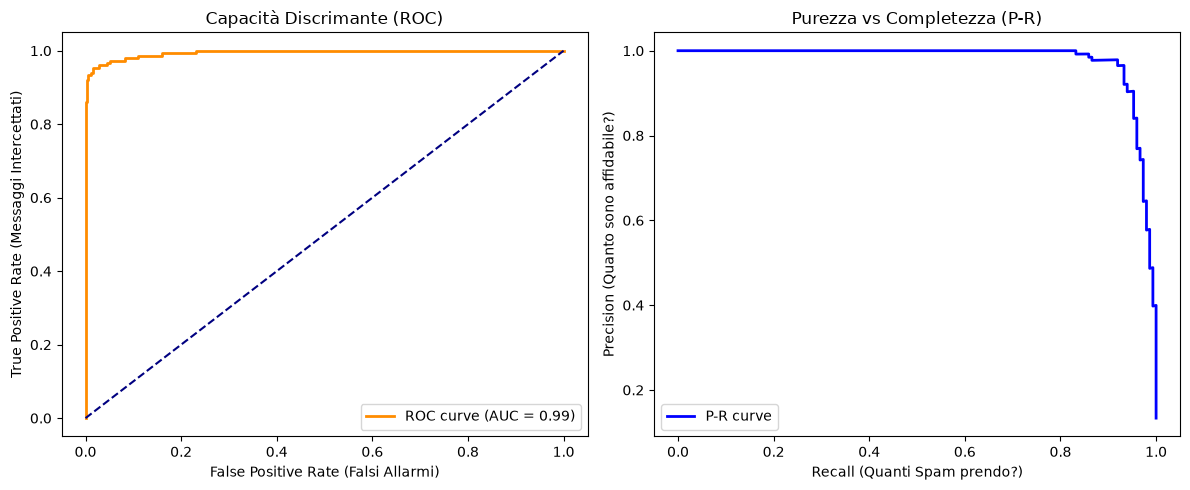


[RISULTATO] Area Sotto la Curva (AUC): 0.9947

 ANALISI OPERATIVA - SOGLIA DECISIONALE (Tau) = 0.5
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.98      0.91      0.94       149

    accuracy                           0.99      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



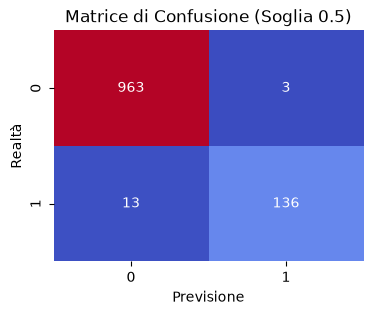


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
 FOCUS ERRORI: I 'FALSI ALLARMI' ALLA SOGLIA 0.5
 Numero totale di messaggi leciti persi: 3
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
- [ERRORE]: Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 cho...
- [ERRORE]: Yalru lyfu astne chikku.. Bt innu mundhe lyf ali halla ke bilo (marriage)program edhae, so lyf is nt yet ovr c...
- [ERRORE]: We are pleased to inform that your application for Airtel Broadband is processed successfully. Your installati...

 ANALISI OPERATIVA - SOGLIA DECISIONALE (Tau) = 0.85
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



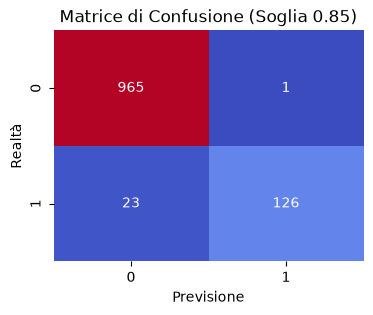


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
 FOCUS ERRORI: I 'FALSI ALLARMI' ALLA SOGLIA 0.85
 Numero totale di messaggi leciti persi: 1
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
- [ERRORE]: Yalru lyfu astne chikku.. Bt innu mundhe lyf ali halla ke bilo (marriage)program edhae, so lyf is nt yet ovr c...

[VERDETTO] F1-Score Finale (Equilibrio Precision/Recall): 0.9444


In [2]:
"""
================================================================================
ESEMPIO PRATICO: VALUTAZIONE DEI MODELLI DI NLP - OLTRE L'ACCURATEZZA
================================================================================
Questo script è stato progettato per dimostrare come valutare un classificatore
di testi (Filtro Spam) utilizzando Keras 3 con backend PyTorch (Best Practice 2026).

Vengono approfonditi i concetti delle slide:
- Matrice di Confusione (TP, FP, FN, TN)
- Precision, Recall e F1-Score
- Trade-off della Soglia (Tau)
- Curve ROC-AUC e Precision-Recall
- Analisi qualitativa degli errori (Falsi Positivi)
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Importiamo le metriche di scikit-learn per la diagnostica professionale
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    fbeta_score, 
    roc_curve, 
    auc, 
    precision_recall_curve
)

# ------------------------------------------------------------------------------
# 1. SETUP DEL BACKEND (Best Practice 2026)
# ------------------------------------------------------------------------------
# Keras 3 è agnostico rispetto al framework. Impostiamo PyTorch come motore di calcolo.
# Questa riga DEVE essere eseguita prima di importare 'keras'.
os.environ["KERAS_BACKEND"] = "torch"
import keras

# ------------------------------------------------------------------------------
# 2. GESTIONE DATI (Preprocessing & Caricamento)
# ------------------------------------------------------------------------------

def carica_e_prepara_dati():
    """
    Scarica il dataset reale 'SMS Spam Collection' e lo prepara per PyTorch.
    
    Il dataset è composto da:
    - Label: 'ham' (posta lecita) o 'spam'
    - Message: Il testo del messaggio SMS
    """
    url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
    # Lettura via Pandas (formato tab-separated)
    df = pd.read_csv(url, sep='\t', names=['label', 'message'])
    
    # Conversione testo: Forziamo il tipo stringa per evitare errori 'object' in PyTorch
    X = df['message'].astype(str).to_numpy()
    
    # Conversione etichette:
    # PyTorch richiede float32 per calcolare la perdita (Loss) binary_crossentropy
    # 0 = Ham (Classe Negativa), 1 = Spam (Classe Positiva)
    y = df['label'].map({'ham': 0, 'spam': 1}).to_numpy(dtype="float32")
    
    # Suddivisione Train/Test (80% / 20%)
    # 'stratify=y' garantisce che la proporzione di Spam sia uguale in entrambi i set
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ------------------------------------------------------------------------------
# 3. ARCHITETTURA DEL MODELLO (Keras Functional API)
# ------------------------------------------------------------------------------

def build_model_nlp(max_tokens=5000, seq_len=50):
    """
    Crea un classificatore NLP neurale.
    Input: Sequenze di numeri interi (ID delle parole).
    """
    # L'input riceve vettori di interi (lunghezza fissa 50 parole)
    inputs = keras.Input(shape=(seq_len,), dtype="int32", name="input_sequenza")
    
    # Layer 1: Embedding - Trasforma ogni ID parola in un vettore denso di 16 dimensioni
    x = keras.layers.Embedding(input_dim=max_tokens, output_dim=16)(inputs)
    
    # Layer 2: Pooling - Riassume il significato del messaggio mediando i vettori delle parole
    x = keras.layers.GlobalAveragePooling1D()(x)
    
    # Layer 3: Dense - Strato 'ragionante' con attivazione ReLU
    x = keras.layers.Dense(16, activation="relu")(x)
    
    # Layer 4: Dropout - Spegne casualmente neuroni per evitare overfitting (memorizzazione)
    x = keras.layers.Dropout(0.1)(x)
    
    # Layer 5: Output - Sigmoid restituisce una probabilità tra 0 e 1 (Slide 10)
    outputs = keras.layers.Dense(1, activation="sigmoid", name="probabilita")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Compilazione: usiamo Adam (ottimizzatore standard) e Binary Crossentropy
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

# ------------------------------------------------------------------------------
# 4. FUNZIONI DI DIAGNOSTICA (Visualizzazione & Statistiche)
# ------------------------------------------------------------------------------

def mostra_diagnostica_avanzata(y_true, y_probs):
    """
    Visualizza le Curve ROC e Precision-Recall.
    Questi grafici mostrano come il modello performa PER TUTTE le possibili soglie.
    """
    # Calcolo coordinate Curva ROC e area AUC (capacità di separazione classi)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    # Calcolo Curva Precision-Recall (quanto è 'pulito' il recupero dei rari spam)
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Grafico ROC: Un modello perfetto va subito in alto a sinistra (AUC=1.0)
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', linestyle='--') # Linea del caso (50/50)
    ax1.set_title('Capacità Discrimante (ROC)')
    ax1.set_xlabel('False Positive Rate (Falsi Allarmi)')
    ax1.set_ylabel('True Positive Rate (Messaggi Intercettati)')
    ax1.legend(loc="lower right")

    # Grafico P-R: Mostra la sfida tra purezza e completezza
    ax2.plot(recall, precision, color='blue', lw=2, label='P-R curve')
    ax2.set_title('Purezza vs Completezza (P-R)')
    ax2.set_xlabel('Recall (Quanti Spam prendo?)')
    ax2.set_ylabel('Precision (Quanto sono affidabile?)')
    ax2.legend(loc="lower left")

    plt.tight_layout()
    plt.show()
    return roc_auc

def mostra_diagnostica_soglia(y_true, y_probs, soglia=0.5):
    """
    Analizza il modello scegliendo una specifica soglia decisionale (Tau).
    Esegue il passaggio fondamentale Probabilità -> Classe Finale.
    """
    # Trasformazione: Se prob > soglia allora è 1 (Spam), altrimenti 0
    y_pred = (y_probs > soglia).astype(int)
    
    print(f"\n" + "="*55)
    print(f" ANALISI OPERATIVA - SOGLIA DECISIONALE (Tau) = {soglia}")
    print("="*55)
    
    # Report testuale con Precision, Recall e F1-Score per ogni classe
    print(classification_report(y_true, y_pred, target_names=["Ham", "Spam"]))
    
    # Matrice di Confusione (Slide 4): Rappresentazione visuale dei 4 quadranti
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='coolwarm', cbar=False)
    plt.title(f'Matrice di Confusione (Soglia {soglia})')
    plt.ylabel('Realtà')
    plt.xlabel('Previsione')
    plt.show()

def analizza_falsi_positivi(X_raw, y_true, y_probs, soglia=0.5):
    """
    IDENTIFICAZIONE ERRORI: Trova i messaggi reali scambiati per spam.
    È l'analisi più importante per non distruggere l'esperienza utente.
    """
    y_pred = (y_probs > soglia).astype(int).flatten()
    
    # Logica booleana: realtà=0 (Lecito) AND previsione=1 (Spam)
    fp_indices = np.where((y_true == 0) & (y_pred == 1))[0]
    
    print(f"\n" + "!"*55)
    print(f" FOCUS ERRORI: I 'FALSI ALLARMI' ALLA SOGLIA {soglia}")
    print(f" Numero totale di messaggi leciti persi: {len(fp_indices)}")
    print("!"*55)
    
    if len(fp_indices) > 0:
        for i in fp_indices[:10]: # Limite a 10 per non intasare la console
            print(f"- [ERRORE]: {X_raw[i][:110]}...") 
    else:
        print("Ottimo! Nessun messaggio lecito è stato erroneamente bloccato.")

# ------------------------------------------------------------------------------
# 5. ESECUZIONE DEL WORKFLOW PROGRAMMATICO
# ------------------------------------------------------------------------------

# STEP 1: Acquisizione Dati
X_train_raw, X_test_raw, y_train, y_test = carica_e_prepara_dati()

# STEP 2: Vettorizzazione (Preprocessing)
# Creiamo un vocabolario delle 5000 parole più frequenti.
vectorizer = keras.layers.TextVectorization(
    max_tokens=5000, 
    output_mode="int", 
    output_sequence_length=50 # Ogni SMS diventa un vettore di 50 numeri
)
# Analizziamo il testo del training per 'imparare' il vocabolario
vectorizer.adapt(X_train_raw)

# Trasformiamo le stringhe in matrici numeriche per il modello PyTorch
X_train = vectorizer(X_train_raw)
X_test = vectorizer(X_test_raw)

# STEP 3: Creazione e Addestramento
modello = build_model_nlp()
print("\n[AI] Addestramento del classificatore in corso...")
modello.fit(X_train, y_train, epochs=8, batch_size=32, verbose=0)

# STEP 4: Inferenza (Predizione)
# Il modello ci dà una lista di probabilità (es. 0.98, 0.12, 0.45...)
y_probs = modello.predict(X_test)

# STEP 5: Valutazione Globale (Curve e AUC)
auc_val = mostra_diagnostica_avanzata(y_test, y_probs)
print(f"\n[RISULTATO] Area Sotto la Curva (AUC): {auc_val:.4f}")

# STEP 6: Confronto Strategico delle Soglie (Slide 9-10)

# CASO A: Soglia Standard (Bilanciata)
# Qui il modello è più "coraggioso", intercetta più spam ma rischia più falsi allarmi.
SOGLIA_STANDARD = 0.5
mostra_diagnostica_soglia(y_test, y_probs, soglia=SOGLIA_STANDARD)
analizza_falsi_positivi(X_test_raw, y_test, y_probs, soglia=SOGLIA_STANDARD)

# CASO B: Soglia Prudente (Alta Precision)
# Alziamo la "manopola" per essere più sicuri prima di bloccare un messaggio.
# Ideale se vogliamo evitare a tutti i costi di censurare mail lecite.
SOGLIA_PRUDENTE = 0.85 
mostra_diagnostica_soglia(y_test, y_probs, soglia=SOGLIA_PRUDENTE)
analizza_falsi_positivi(X_test_raw, y_test, y_probs, soglia=SOGLIA_PRUDENTE)

# STEP 7: Verdetto Finale (F1-Score)

# Calcolo dell'ago della bilancia (Slide 11-12) alla soglia standard.
f1 = fbeta_score(y_test, (y_probs > 0.5).astype(int), beta=1)
print(f"\n[VERDETTO] F1-Score Finale (Equilibrio Precision/Recall): {f1:.4f}")